# Selected Experiment Metrics Summary

This notebook summarizes the selected CE1 experiment results from `results/` and local `wandb/` folders.

The table includes the February RBC baseline: `rbc_baseline_vt_february`.

The table is sorted by `primary_rank_score`, where lower is better:

- 30% load-tracking CV-RMSE rank
- 30% absolute NMBE rank
- 30% Thermal Comfort group rank
- 10% selected secondary-metrics group rank

Formula:

`primary_rank_score = 0.30 * rank(primary_load_cv_rmse_pct) + 0.30 * rank(|primary_load_nmbe_pct|) + 0.30 * average_rank(Thermal Comfort metrics) + 0.10 * average_rank(selected secondary metrics)`

Thermal Comfort metrics used here are:

- `primary_comfort_exceedance_pct`
- `primary_comfort_exceedance_hours_total`
- `primary_comfort_exceedance_hours_mean`
- `primary_comfort_exceedance_hours_max`

Selected secondary metrics used here are:

- `kpi_electricity_consumption`
- `kpi_ramping`
- `kpi_daily_peak`
- `secondary_peak_demand_change_pct`
- `secondary_site_energy_change_pct`

Each component rank is computed in ascending order, so smaller metric values receive better ranks.

In [50]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

REPO_DIR = Path.cwd()
if not (REPO_DIR / 'results').exists():
    REPO_DIR = REPO_DIR.parent

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

import tools.summarize_selected_experiment_metrics as summary_mod
summary_mod = importlib.reload(summary_mod)

MARKDOWN_COLUMNS = summary_mod.MARKDOWN_COLUMNS
SELECTED_EXPERIMENTS = summary_mod.SELECTED_EXPERIMENTS
SUMMARY_COLUMNS = summary_mod.SUMMARY_COLUMNS
_add_primary_ranking = summary_mod._add_primary_ranking
_build_row = summary_mod._build_row
_write_markdown_table = summary_mod._write_markdown_table

OUTPUT_ROOT = REPO_DIR / 'experiment_metric_summary'
WANDB_ROOT = REPO_DIR / 'wandb'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f'Repo: {REPO_DIR}')
print(f'Output: {OUTPUT_ROOT}')


Repo: /home/yue/EthanZhu/annex96_common_exercise_1
Output: /home/yue/EthanZhu/annex96_common_exercise_1/experiment_metric_summary


## Selected Experiments

In [51]:
pd.DataFrame({'experiment': SELECTED_EXPERIMENTS})

,experiment
0,rbc_baseline_vt_february
1,mappo_standard_vt_500_final
2,mappo_grouped_vt_500_final
3,mappo_grouped_comm_v2_vt_500_final
4,mappo_grouped_tarmac_vt_500_final
5,mappo_grouped_gat_vt_500_final
6,mappo_grouped_powernet_vt_500_final
7,mappo_grouped_powernet_global_vt_500_final
8,mappo_grouped_commnet_vt_500_final
9,mappo_grouped_dial_vt_500_final


## Build Summary Table

In [52]:
rows = [_build_row(experiment, WANDB_ROOT) for experiment in SELECTED_EXPERIMENTS]
df = _add_primary_ranking(pd.DataFrame(rows))

all_columns = SUMMARY_COLUMNS + [column for column in df.columns if column not in SUMMARY_COLUMNS]
df = df.loc[:, [column for column in all_columns if column in df.columns]]

full_csv = OUTPUT_ROOT / 'selected_experiment_metrics_full.csv'
report_csv = OUTPUT_ROOT / 'selected_experiment_metrics_report_table.csv'
markdown_path = OUTPUT_ROOT / 'selected_experiment_metrics_report_table.md'

df.to_csv(full_csv, index=False)
df.loc[:, [column for column in SUMMARY_COLUMNS if column in df.columns]].to_csv(report_csv, index=False)
_write_markdown_table(markdown_path, df, MARKDOWN_COLUMNS)

print(f'Full metrics table -> {full_csv}')
print(f'Report table -> {report_csv}')
print(f'Markdown table -> {markdown_path}')


Full metrics table -> /home/yue/EthanZhu/annex96_common_exercise_1/experiment_metric_summary/selected_experiment_metrics_full.csv
Report table -> /home/yue/EthanZhu/annex96_common_exercise_1/experiment_metric_summary/selected_experiment_metrics_report_table.csv
Markdown table -> /home/yue/EthanZhu/annex96_common_exercise_1/experiment_metric_summary/selected_experiment_metrics_report_table.md


## Report Table

In [53]:
report_columns = [column for column in MARKDOWN_COLUMNS if column in df.columns]
report_view = df[report_columns].set_index('primary_rank')
display(report_view)

,experiment,primary_rank_score,primary_load_cv_rmse_pct,primary_load_nmbe_pct,primary_comfort_exceedance_pct,primary_comfort_exceedance_hours_total,primary_comfort_exceedance_hours_mean,primary_comfort_exceedance_hours_max,test_reward_sum,kpi_electricity_consumption,kpi_ramping,kpi_daily_peak,secondary_peak_demand_change_pct,secondary_site_energy_change_pct,wandb_run_id
primary_rank,,,,,,,,,,,,,,,
1,mappo_grouped_comm_v2_vt_500_final,2.800,49.9360,-17.7413,47.5060,7981.0,319.24,671.0,-22907.8639,1.1021,1.1592,1.0407,-2.1036,10.2055,hmdcbj2c
2,sb3_independent_sac_vt_50_final,4.570,51.8727,-18.7886,48.4762,8144.0,325.76,672.0,-15769.3593,1.0618,0.9905,1.0102,-10.9652,6.1763,kru9ntwg
3,mappo_grouped_tarmac_vt_500_final,4.780,50.9250,-18.5564,48.8869,8213.0,328.52,672.0,-24165.2505,1.0983,1.2062,1.0436,-4.4682,9.8317,g6o68ph0
4,mappo_grouped_gat_vt_500_final,5.730,56.1046,-16.6212,46.9167,7882.0,315.28,672.0,-21774.5339,1.1382,1.3597,1.0990,-2.7197,13.8176,63msj7dg
5,mappo_grouped_comm_weighted_a090_b010_vt_500_f...,6.265,52.2456,-18.9314,50.3036,8451.0,338.04,672.0,-26034.5090,1.0832,1.1398,1.0511,-5.1421,8.3178,d2ufgjyr
6,mappo_grouped_comm_weighted_default_vt_500_final,6.275,55.0538,-18.0635,48.4940,8147.0,325.88,669.0,-38047.5110,1.1097,1.1959,1.1061,-7.7428,10.9651,49wv21gn
7,mappo_grouped_powernet_vt_500_final,7.070,55.4132,-19.1565,48.2143,8100.0,324.00,670.0,-27805.0000,1.0989,1.2751,1.0605,-8.8996,9.8928,v9rnhpdr
8,mappo_grouped_comm_weighted_a055_b045_vt_500_f...,8.145,52.5812,-19.6803,50.9583,8561.0,342.44,661.0,-42622.6204,1.1023,1.1402,1.0156,-9.7877,10.2272,47ney6ne
9,rllib_independent_ppo_vt_42_final,8.370,51.7825,-21.8354,63.2560,10627.0,425.08,672.0,-79395.8399,1.0367,1.0102,0.9903,-11.4869,3.6674,8v55jxl2


## Primary Metrics Plots

Plot -> /home/yue/EthanZhu/annex96_common_exercise_1/experiment_metric_summary/selected_experiment_primary_metrics.png


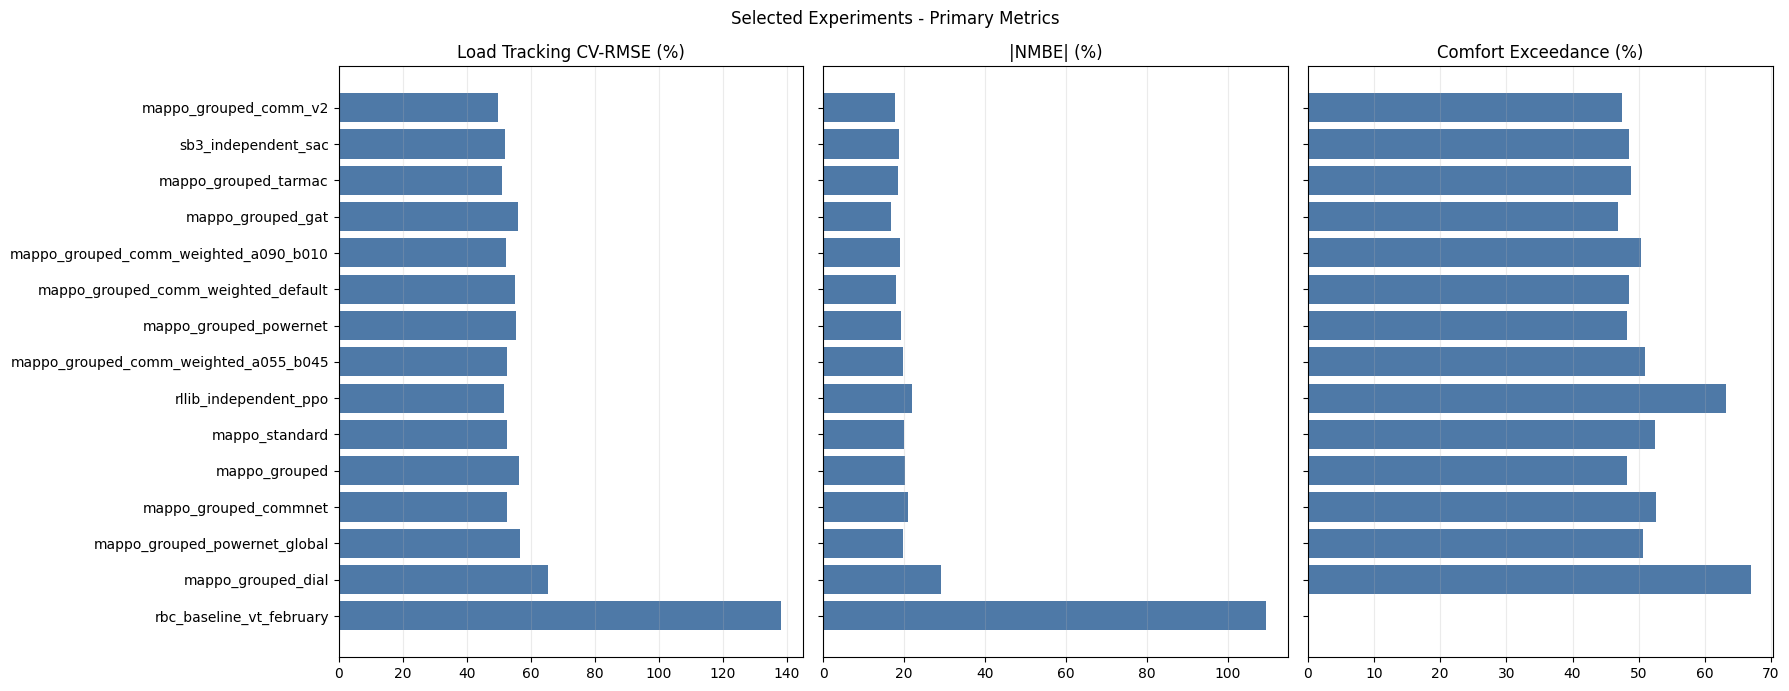

In [54]:
plot_df = df.sort_values('primary_rank').copy()
labels = plot_df['experiment'].str.replace('_vt_500_final', '', regex=False)
labels = labels.str.replace('_vt_42_final', '', regex=False)
labels = labels.str.replace('_vt_50_final', '', regex=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

metrics = [
    ('primary_load_cv_rmse_pct', 'Load Tracking CV-RMSE (%)'),
    ('primary_abs_nmbe_pct', '|NMBE| (%)'),
    ('primary_comfort_exceedance_pct', 'Comfort Exceedance (%)'),
]

for ax, (column, title) in zip(axes, metrics):
    ax.barh(labels, plot_df[column], color='#4e79a7')
    ax.invert_yaxis()
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.25)

fig.suptitle('Selected Experiments - Primary Metrics')
fig.tight_layout()

plot_path = OUTPUT_ROOT / 'selected_experiment_primary_metrics.png'
fig.savefig(plot_path, dpi=180, bbox_inches='tight')
print(f'Plot -> {plot_path}')
plt.show()


## Secondary Metrics Plots

Plot -> /home/yue/EthanZhu/annex96_common_exercise_1/experiment_metric_summary/selected_experiment_secondary_metrics.png


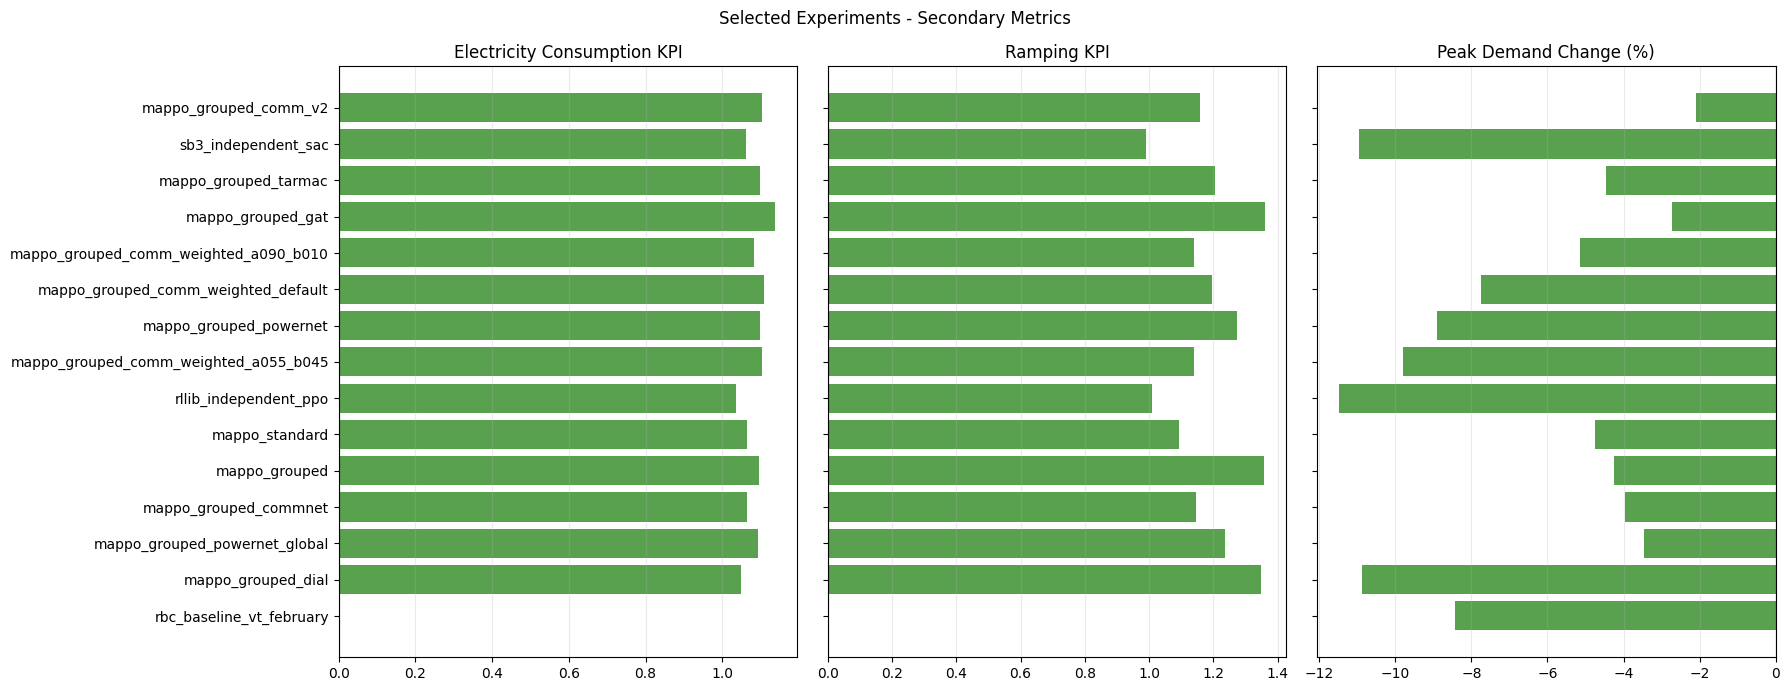

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

secondary_metrics = [
    ('kpi_electricity_consumption', 'Electricity Consumption KPI'),
    ('kpi_ramping', 'Ramping KPI'),
    ('secondary_peak_demand_change_pct', 'Peak Demand Change (%)'),
]

for ax, (column, title) in zip(axes, secondary_metrics):
    ax.barh(labels, plot_df[column], color='#59a14f')
    ax.axvline(0, color='black', linewidth=0.8, alpha=0.5)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.25)

fig.suptitle('Selected Experiments - Secondary Metrics')
fig.tight_layout()

plot_path = OUTPUT_ROOT / 'selected_experiment_secondary_metrics.png'
fig.savefig(plot_path, dpi=180, bbox_inches='tight')
print(f'Plot -> {plot_path}')
plt.show()


## W&B Match Check

In [56]:
wandb_check_columns = ['experiment', 'wandb_run_id', 'wandb_started_at', 'wandb_program', 'wandb_run_dir']
display(df[[column for column in wandb_check_columns if column in df.columns]])

,experiment,wandb_run_id,wandb_started_at,wandb_program,wandb_run_dir
0,mappo_grouped_comm_v2_vt_500_final,hmdcbj2c,2026-04-21T04:22:48.051394Z,-m mappo_grouped_comm_v2.train,wandb/run-20260421_142248-hmdcbj2c
1,sb3_independent_sac_vt_50_final,kru9ntwg,2026-04-23T04:33:19.608286Z,-m sb3_independent_sac.train,wandb/run-20260423_123319-kru9ntwg
2,mappo_grouped_tarmac_vt_500_final,g6o68ph0,2026-04-21T21:18:45.699930Z,-m mappo_grouped_tarmac.train,wandb/run-20260422_071845-g6o68ph0
3,mappo_grouped_gat_vt_500_final,63msj7dg,2026-04-22T14:31:41.277248Z,-m mappo_grouped_gat.train,wandb/run-20260422_223141-63msj7dg
4,mappo_grouped_comm_weighted_a090_b010_vt_500_f...,d2ufgjyr,2026-04-22T14:31:41.199612Z,-m mappo_grouped_comm_weighted.train,wandb/run-20260422_223141-d2ufgjyr
5,mappo_grouped_comm_weighted_default_vt_500_final,49wv21gn,2026-04-22T14:31:41.825582Z,-m mappo_grouped_comm_weighted.train,wandb/run-20260422_223141-49wv21gn
6,mappo_grouped_powernet_vt_500_final,v9rnhpdr,2026-04-22T14:31:41.157032Z,-m mappo_grouped_powernet.train,wandb/run-20260422_223141-v9rnhpdr
7,mappo_grouped_comm_weighted_a055_b045_vt_500_f...,47ney6ne,2026-04-22T14:31:41.329708Z,-m mappo_grouped_comm_weighted.train,wandb/run-20260422_223141-47ney6ne
8,rllib_independent_ppo_vt_42_final,8v55jxl2,2026-04-23T04:29:05.018778Z,-m rllib_independent_ppo.train,wandb/run-20260423_122905-8v55jxl2
9,mappo_standard_vt_500_final,2ownbj08,2026-04-20T15:44:45.365025Z,-m mappo_standard.train,wandb/run-20260421_014445-2ownbj08
